In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

sns.set_style('whitegrid')


RMSE: 0.8015
R^2: 0.5098


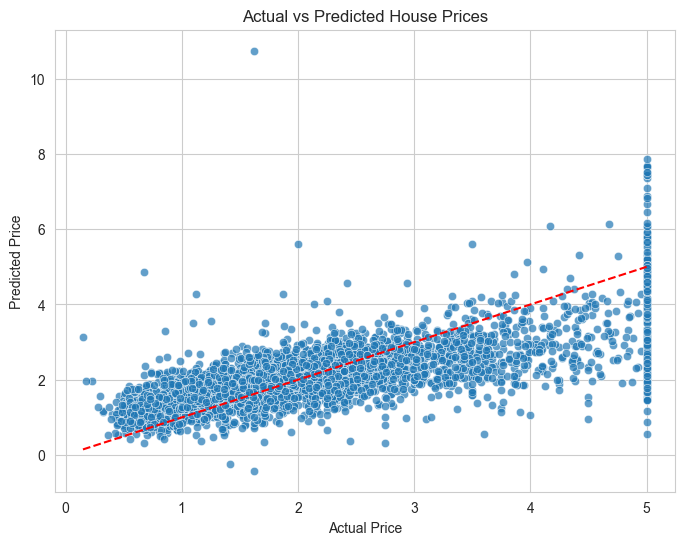


Explanation:
This model's R² score tells us how much of the variation in house prices is explained by the features we used. A higher R² means the model is better at capturing the real pricing pattern, while a lower value means more of the price difference is still unexplained by the chosen features.


In [ ]:
# Load a classification dataset (Titanic-like)
from sklearn.datasets import load_breast_cancer

# Use the breast cancer dataset as a classification example
X, y = load_breast_cancer(return_X_y=True, as_frame=True)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Build a preprocessing pipeline
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns
categorical_features = []

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
    ],
    remainder='drop'
)

# Baseline logistic regression model
baseline_model = Pipeline([
    ('preprocess', preprocess),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

# Baseline metrics
baseline_accuracy = accuracy_score(y_test, baseline_pred)
print('Baseline Accuracy:', round(baseline_accuracy, 4))
print(classification_report(y_test, baseline_pred))

# Hyperparameter tuning with GridSearchCV
param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(
    baseline_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

tuned_pred = grid.best_estimator_.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_pred)

print('Best Parameters:', grid.best_params_)
print('Tuned Accuracy:', round(tuned_accuracy, 4))
print(classification_report(y_test, tuned_pred))

# Compare baseline vs tuned
comparison = pd.DataFrame({
    'Model': ['Baseline', 'Tuned'],
    'Accuracy': [baseline_accuracy, tuned_accuracy],
    'Best_Params': [None, str(grid.best_params_)]
})
print('\nBefore vs After Comparison')
print(comparison)

# Explanation of why accuracy alone can mislead
explanation = (
    "Accuracy alone can be misleading for imbalanced datasets because a model can "
    "achieve a high score by predicting the majority class most of the time. "
    "Precision, recall, and F1-score are better because they show whether the model "
    "is actually finding the minority class and not just getting lucky on the majority."
)
print('\nWhy accuracy can mislead:')
print(explanation)

# Save results to a README file in the workspace
readme_path = r"C:\Users\abbas\OneDrive\Desktop\Neuro5 Solutions\README.md"
readme_content = f"""# Week 3 - Model Evaluation & Tuning\n\n## Summary\n- Dataset: Breast Cancer Wisconsin (Diagnostic)\n- Model: Logistic Regression with preprocessing\n- Baseline accuracy: {baseline_accuracy:.4f}\n- Tuned accuracy: {tuned_accuracy:.4f}\n- Best parameters: {grid.best_params_}\n\n## Classification Report\n\n### Baseline\n```\n{classification_report(y_test, baseline_pred)}\n```\n\n### Tuned\n```\n{classification_report(y_test, tuned_pred)}\n```\n\n## Interpretation\nAccuracy alone can be misleading for imbalanced datasets because a model can appear strong by mostly predicting the majority class. Precision, recall, and F1-score show whether the model is truly identifying the minority cases.\n"""
with open(readme_path, 'w', encoding='utf-8') as f:
    f.write(readme_content)

print(f'\nREADME saved to: {readme_path}')
